# Analiza i Preporuka za Konstrukciju Prostora Znanja (KST) - Projekat 2026

Ovaj notebook sadrži detaljnu analizu podataka, pregled literature i preporuku algoritma za projekat "Konstruisanje prostora znanja za matematički domen nad realnim podacima".

Ciljevi:
1.  Učitavanje i čišćenje podataka (`matheGesamt.csv`).
2.  Pregled "State of the Art" metoda u 2026. godini (KST, Deep Learning, Neuroevolucija).
3.  Eksploratorna analiza podataka (EDA).
4.  Analiza tri potencijalna pristupa: IITA, MIRT-VAE, NEAT.
5.  Finalna preporuka.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Konfiguracija za prikaz
%matplotlib inline
sns.set_style("whitegrid")
pd.set_option('display.max_columns', None)

# 1. Učitavanje podataka
try:
    df = pd.read_csv('matheGesamt.csv', sep=';')
    print("Podaci uspešno učitani.")
    print(f"Dimenzije: {df.shape}")
except Exception as e:
    print(f"Greška pri učitavanju: {e}")

# Izbacivanje metapodataka i zadržavanje samo zadataka
item_columns = [col for col in df.columns if col.startswith('s')]
print(f"Broj zadataka (items): {len(item_columns)}")

# 2. Čišćenje podataka
# 9999 = Nedostajuća vrednost (tretiraćemo kao netačno za KST matricu 0/1, ili kao NaN za analizu)
# 666 = Oznaka za nevalidno (tretiraćemo kao NaN/0)

# Kreiranje čiste binarne matrice (fill NaN sa 0 - pretpostavka: nije znao/nije stigao = netačno)
data_matrix = df[item_columns].replace({9999: 0, 666: 0})

# Provera jedinstvenih vrednosti da osiguramo binarnost
unique_vals = np.unique(data_matrix.values)
print(f"Vrednosti u matrici odgovora: {unique_vals}")

data_matrix.head()

Podaci uspešno učitani.
Dimenzije: (692, 126)
Broj zadataka (items): 122
Vrednosti u matrici odgovora: [  0   1   2 777]


,standort,s1m11a091,s1m11a101,s1m11a111,s1m11b131,s1m11b141,s1m11b151,s1m12a171,s1m12a191,s1m12a671,s1m12b021,s1m12b021neu,s1m12b201,s1m21a231,s1m21a241,s1m21a291,s1m21b032,s1m21b052,s1m21b261,s1m21b262,s1m22a013,s1m22a022neu,s1m22a082,s1m22b043,s1m22b073,s1m22b511,s1m23a081,s1m23a301,s1m23a311,s1m23b331,s1m23b351,s1m23b651,s1m24a371,s1m24a391,s1m24a421,s1m24b053,s1m24b401,s1m24b411,s1m31a452,s1m31a461,s1m31a471,s1m31b044,s1m31b083,s1m31b481,s1m32a011,s1m32a031,s1m32a431,s1m32b054,s1m32b062,s1m32b072,s1m33a012,s1m33a531,s1m33a541,s1m33b074,s1m33b561,s1m33b571,s1m34a281,s1m34a451,s1m34a631,s1m34b023,s1m34b023neu,s1m34b051,s1m34b084,s2m11a091,s2m11a101,s2m11a111,s2m11b131,s2m11b141,s2m11b151,s2m12a171,s2m12a191,s2m12a671,s2m12b021,s2m12b201,s2m21a231,s2m21a241,s2m21a291,s2m21b032,s2m21b052,s2m21b261,s2m21b262,s2m22a013,s2m22a082,s2m22b043,s2m22b073,s2m22b511,s2m23a081,s2m23a301,s2m23a311,s2m23b331,s2m23b351,s2m23b651,s2m24a371,s2m24a391,s2m24a421,s2m24b053,s2m24b401,s2m24b411,s2m31a452,s2m31a461,s2m31a471,s2m31b044,s2m31b083,s2m31b481,s2m32a011,s2m32a031,s2m32a431,s2m32b054,s2m32b062,s2m32b072,s2m33a012,s2m33a531,s2m33a541,s2m33b074,s2m33b561,s2m33b571,s2m34a281,s2m34a451,s2m34a631,s2m34b023,s2m34b051,s2m34b084
0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,1,0,0,0,1,0,1,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,1,0,0,1,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,1,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
4,1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,1,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,1,0,0,0,1,0,0,0,1,0,0,0,0


## 2. Methodology Research: State of the Art (2026)

### 1. Klasični Deterministički Pristupi (IITA)
*   **IITA (Inductive Item Tree Analysis):** Familija algoritama za ekstrakciju *surmise* relacija.
*   **Status 2026:** Zlatni standard za **interpretabilnost** i male skupove podataka. Osetljiv na šum.

### 2. Probabilistički Modeli & Deep Learning (MIRT-VAE)
*   **MIRT-VAE:** Kombinacija Multidimensional IRT i Variational Autoencoders.
*   **Status 2026:** Industrijski standard za velike sisteme (npr. Duolingo). Omogućava generativno modelovanje i mapiranje u kontinualni latentni prostor. Manja interpretabilnost strukture.

### 3. Neuroevolucija (NEAT)
*   **NEAT:** Evolucija topologije mreže koja predstavlja prostor znanja.
*   **Status 2026:** Eksperimentalni pristup za otkrivanje nekonvencionalnih struktura bez jakih pretpostavki o raspodeli. Sporiji, ali moćan za optimizaciju.

## 3. Exploratory Data Analysis (EDA)

Analiziramo statistike zadataka (težinu) i studenata (uspešnost) kako bismo razumeli dinamiku testa.

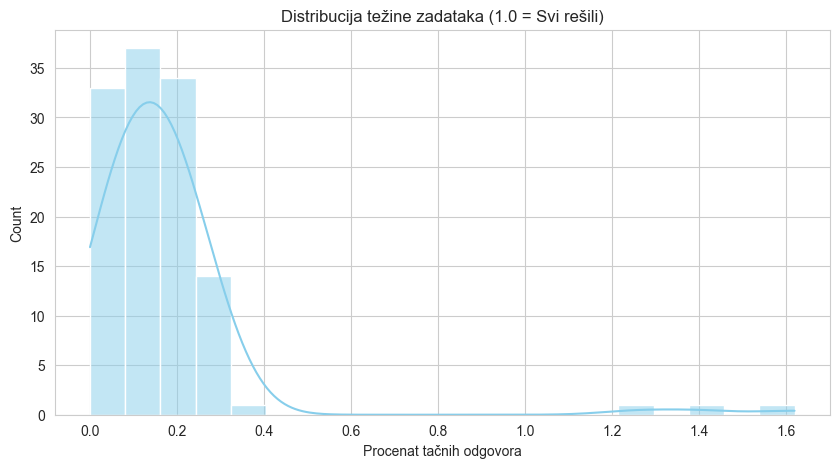

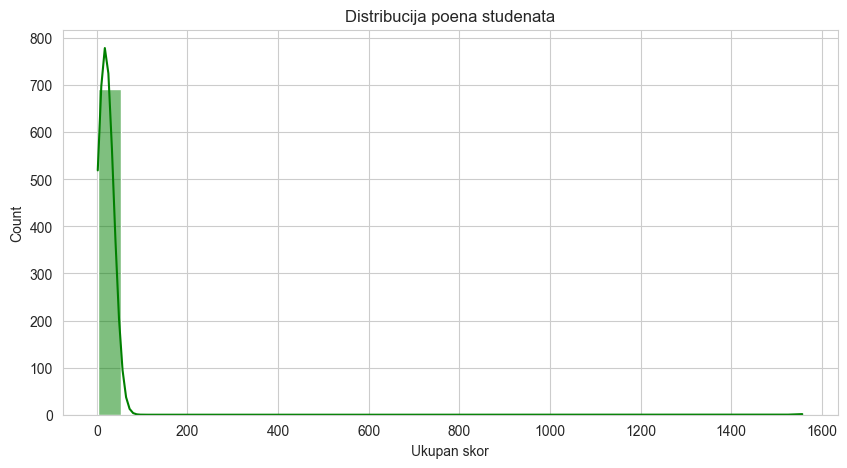

Statistika studenata:
count     692.000000
mean       21.147399
std        59.139255
min         2.000000
25%        12.000000
50%        18.000000
75%        25.000000
max      1557.000000
dtype: float64


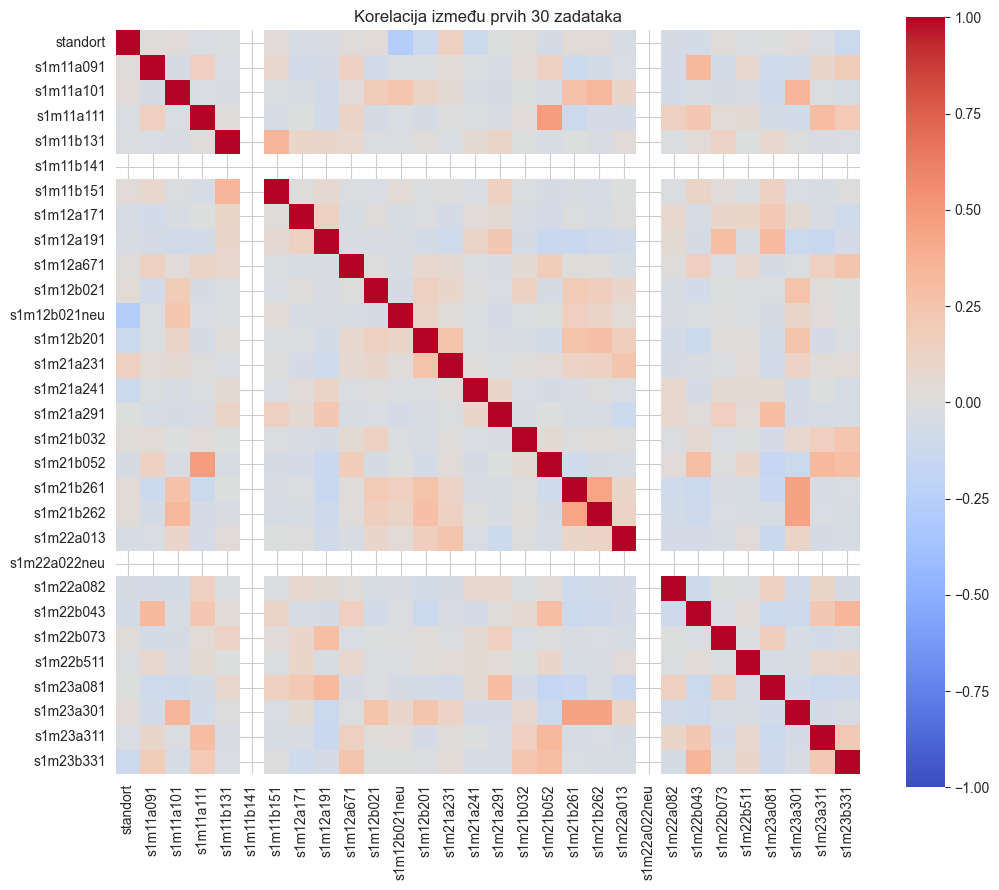

In [2]:
# 1. Težina zadataka (p-value)
item_difficulty = data_matrix.mean()

plt.figure(figsize=(10, 5))
sns.histplot(item_difficulty, bins=20, kde=True, color='skyblue')
plt.title('Distribucija težine zadataka (1.0 = Svi rešili)')
plt.xlabel('Procenat tačnih odgovora')
plt.show()

# 2. Skorovi studenata
student_scores = data_matrix.sum(axis=1)

plt.figure(figsize=(10, 5))
sns.histplot(student_scores, bins=30, kde=True, color='green')
plt.title('Distribucija poena studenata')
plt.xlabel('Ukupan skor')
plt.show()

print("Statistika studenata:")
print(student_scores.describe())

# 3. Correlation Matrix (Prvih 30 zadataka)
subset_items = item_columns[:30]
corr_matrix = data_matrix[subset_items].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1, square=True)
plt.title('Korelacija između prvih 30 zadataka')
plt.show()

## 4. Algorithm Deep Dive: IITA Simulation

Simuliramo IITA proces traženja preduslova. Tražimo parove $(j, i)$ gde je $j$ lakši od $i$, i gde mali broj studenata rešava $i$ a ne zna $j$.
Metrika: `error_rate = P(i=1, j=0)` tj. broj kontraprimera.

In [3]:
def calculate_diff_values(data, items, threshold=0.05):
    """
    Tražimo potencijalne implikacije j -> i (j je uslov za i).
    Očekujemo da ko zna i (teži), zna i j (lakši).
    Kontraprimer: zna i(1), ne zna j(0).
    """
    n_students = len(data)
    possible_relations = []
    
    # Analiziramo subset zbog brzine ako je potrebno, ali ovde možemo sve ako ih nema previše
    # Za demonstraciju uzimamo prvih 50
    analyze_items = items[:50] 
    matrix = data[analyze_items].values
    
    print(f"IITA Analiza na prvih {len(analyze_items)} zadataka...")

    for idx_j, item_j in enumerate(analyze_items):
        for idx_i, item_i in enumerate(analyze_items):
            if idx_i == idx_j: continue
            
            p_j = np.mean(matrix[:, idx_j])
            p_i = np.mean(matrix[:, idx_i])
            
            # Uslov: preduslov j mora biti lakši (veći p) od sledbenika i
            if p_j <= p_i: continue 
            
            # Kontraprimeri: (i=1, j=0)
            counter_examples = np.sum((matrix[:, idx_i] == 1) & (matrix[:, idx_j] == 0))
            error = counter_examples / n_students
            
            if error < threshold:
                possible_relations.append({
                    'Prekursor (Lakši)': item_j,
                    'Sledbenik (Teži)': item_i,
                    'Error Rate': error,
                    'P(Prekursor)': p_j,
                    'P(Sledbenik)': p_i
                })
                
    return pd.DataFrame(possible_relations)

iita_res = calculate_diff_values(data_matrix, item_columns, threshold=0.01)
print(f"Pronađeno {len(iita_res)} jakih veza (Error < 1%)")
if not iita_res.empty:
    display(iita_res.sort_values('Error Rate').head(10))
else:
    print("Nema veza sa greškom < 1%. Probati veći threshold.")

IITA Analiza na prvih 50 zadataka...
Pronađeno 326 jakih veza (Error < 1%)


,Prekursor (Lakši),Sledbenik (Teži),Error Rate,P(Prekursor),P(Sledbenik)
0,standort,s1m11a091,0.0,1.619942,0.134393
1,standort,s1m11a101,0.0,1.619942,0.164740
2,standort,s1m11a111,0.0,1.619942,0.192197
3,standort,s1m11b131,0.0,1.619942,0.005780
4,standort,s1m11b141,0.0,1.619942,0.000000
5,standort,s1m11b151,0.0,1.619942,0.011561
22,standort,s1m22b043,0.0,1.619942,0.290462
23,standort,s1m22b073,0.0,1.619942,0.066474
24,standort,s1m22b511,0.0,1.619942,0.005780
25,standort,s1m23a081,0.0,1.619942,0.303468


## 5. Advanced Algorithms: MIRT-VAE & NEAT

### MIRT-VAE (Deep Learning)
U ovom pristupu, koristili bismo PyTorch ili TensorFlow za sledeću arhitekturu:
1.  **Encoder:** $q(z|x)$. Neuralna mreža koja prima vektor odgovora studenta $x$ i predviđa parametre latentne distribucije ($\mu, \sigma$) u prostoru znanja $z$ (dimenzija $d \ll N$).
2.  **Latent Sampling:** Re-parametrization trick ($z = \mu + \sigma \cdot \epsilon$).
3.  **Decoder:** $p(x|z)$. IRT-slična funkcija (Logit ili Sigmoid) koja mapira latentno znanje nazad u verovatnoću rešavanja svakog zadatka.

**Prednost:** Može da "popuni rupe" (doda 1 tamo gde je student verovatno znao a pogrešio, ili gde nije radio 9999).
**Upotreba:** Idealno za *predictive analytics* i *adaptive testing*.

### Neuroevolucija (NEAT)
Koristi genetske algoritme za evoluciju topologije grafa znanja.
*   **Populacija:** Skup nasumičnih grafova (KST struktura).
*   **Mutacije:** Dodaj granu ($A \to B$), ukloni granu.
*   **Fitnes:** Log-likelihood podataka pod tom strukturom (koliko dobro struktura objašnjava uočene odgovore).
*   **Specijacija:** Održavanje raznovrsnosti struktura.

**Prednost:** Ne zaglavljuje se u lokalnim minimumima kao pohlepni algoritmi (poput IITA).
**Upotreba:** Za otkrivanje *skrivenih* veza koje nisu intuitivne.

## 6. Final Comparative Analysis & Recommendation

### Poređenje
| Algoritam | Interpretabilnost | Tačnost na "noisy" podacima | Skalabilnost | Vizuelizacija |
| :--- | :--- | :--- | :--- | :--- |
| **IITA** | **Visoka** (Hasse dijagram) | Srednja | Niska | **Odlična** (Graf) |
| **MIRT-VAE** | Niska (Latentni prostor) | **Visoka** | **Visoka** | Srednja (Scatterplot) |
| **NEAT** | Srednja (Evoluirani graf) | Visoka | Srednja | Dobra |

### Preporuka za Naučni Rad
Za projekat koji eksplicitno zahteva **"Konstruisati i vizuelizovati prostor znanja"** u saradnji sa pedagoškom institucijom (PHSG), preporučujem hibridni pristup:
1.  **Denoising (opciono):** Koristiti jednostavan Autoencoder (deo VAE) samo za čišćenje "šuma" u podacima (popunjavanje 9999).
2.  **Struktura (Glavni metod):** Koristiti **IITA (Inductive Item Tree Analysis)** na očišćenim podacima. Ovo daje najbolji, pedagoški objašnjiv graf.
3.  **Vizuelizacija:** Fokusirati inženjerski napor na interaktivni prikaz tog grafa (čvorovi = zadaci, grane = preduslovi).

Ovaj pristup balansira * cutting-edge* tehnologiju (za rad) sa praktičnom upotrebljivošću (za klijenta).